In [3]:
import pandas as pd

df = pd.read_csv("C:\ZEEL\projects\supply-chain-analytics\data\supply_chain_final.csv")

<>:3: SyntaxWarning: invalid escape sequence '\Z'
<>:3: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\asus\AppData\Local\Temp\ipykernel_432\1105242748.py:3: SyntaxWarning: invalid escape sequence '\Z'
  df = pd.read_csv("C:\ZEEL\projects\supply-chain-analytics\data\supply_chain_final.csv")


In [4]:
# target
y = df["Late_delivery_risk"]

In [5]:
print(df.columns.tolist())

['Type', 'Days_for_shipping_real', 'Days_for_shipment_scheduled', 'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status', 'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Fname', 'Customer_Id', 'Customer_Lname', 'Customer_Segment', 'Customer_State', 'Customer_Street', 'Customer_Zipcode', 'Department_Id', 'Department_Name', 'Latitude', 'Longitude', 'Market', 'Order_City', 'Order_Country', 'Order_Customer_Id', 'Order_Date', 'Order_Id', 'Order_Item_Cardprod_Id', 'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Id', 'Order_Item_Product_Price', 'Order_Item_Profit_Ratio', 'Order_Item_Quantity', 'Sales', 'Order_Item_Total', 'Order_Profit_Per_Order', 'Order_Region', 'Order_State', 'Order_Status', 'Product_Card_Id', 'Product_Category_Id', 'Product_Name', 'Product_Price', 'Product_Status', 'Shipping_Date', 'Shipping_Mode']


In [24]:
features = [
    "Days_for_shipment_scheduled",
    "Order_Item_Quantity",
    "Order_Item_Discount_Rate",
    "Order_Item_Product_Price",
    "Order_Item_Profit_Ratio",
    "Sales",
    "Category_Name",
    "Shipping_Mode",
    "Market",
    "Order_Region",
    "Order_Country",
    "Customer_Segment",
    "Department_Name"
]

X = df[features]

y = df["Late_delivery_risk"]

In [25]:
X.isnull().sum()

Days_for_shipment_scheduled    0
Order_Item_Quantity            0
Order_Item_Discount_Rate       0
Order_Item_Product_Price       0
Order_Item_Profit_Ratio        0
Sales                          0
Category_Name                  0
Shipping_Mode                  0
Market                         0
Order_Region                   0
Order_Country                  0
Customer_Segment               0
Department_Name                0
dtype: int64

In [26]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [27]:
import sys
print(sys.executable)

c:\ZEEL\projects\supply-chain-analytics\venv\Scripts\python.exe


In [28]:
!where python

c:\ZEEL\projects\supply-chain-analytics\venv\Scripts\python.exe
C:\Users\asus\anaconda3\python.exe
C:\Users\asus\AppData\Local\Programs\Python\Python313\python.exe
C:\Users\asus\AppData\Local\Microsoft\WindowsApps\python.exe


In [29]:
import sys
!{sys.executable} -m pip install scikit-learn

In [30]:
import sklearn
print(sklearn.__version__)

1.9.0


In [31]:
import sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Accuracy:
0.6915577221360514

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16307
           1       0.84      0.54      0.66     19797

    accuracy                           0.69     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.69      0.69     36104



In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [38]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
0.6886771548858852

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.82      0.70     16307
           1       0.80      0.58      0.67     19797

    accuracy                           0.69     36104
   macro avg       0.71      0.70      0.69     36104
weighted avg       0.72      0.69      0.69     36104



In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

                                           Feature  Importance
0                      Days_for_shipment_scheduled    0.423874
57                    Shipping_Mode_Standard Class    0.362139
56                      Shipping_Mode_Second Class    0.117807
55                          Shipping_Mode_Same Day    0.043115
4                          Order_Item_Profit_Ratio    0.008283
2                         Order_Item_Discount_Rate    0.006687
5                                            Sales    0.003700
3                         Order_Item_Product_Price    0.002253
1                              Order_Item_Quantity    0.002139
247                     Customer_Segment_Corporate    0.001707
121                             Order_Country_Cuba    0.001346
248                   Customer_Segment_Home Office    0.001227
251                       Department_Name_Fan Shop    0.000501
111                           Order_Country_Canada    0.000473
206  Order_Country_República Democrática del Congo    0

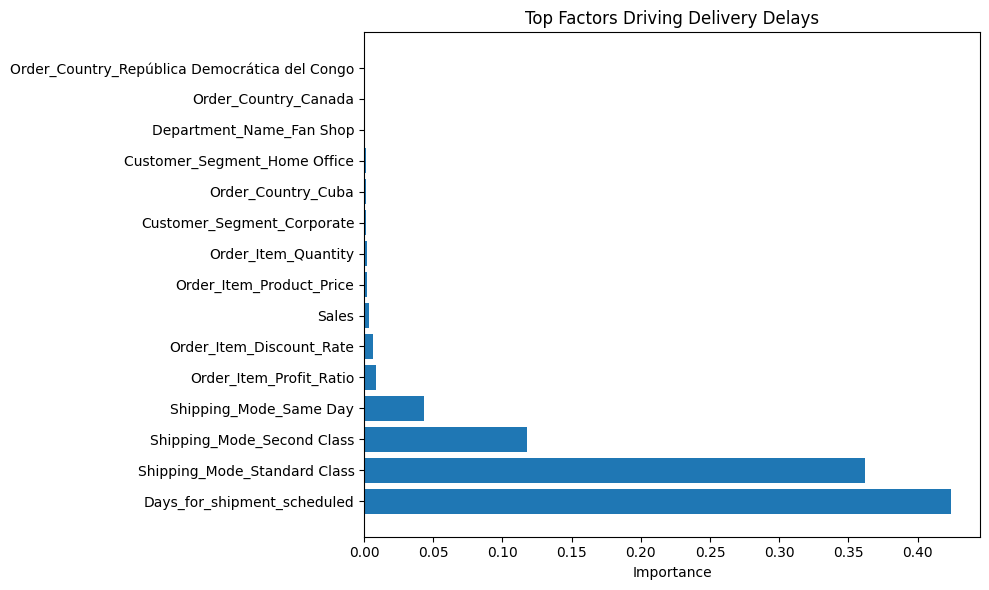

In [40]:
import matplotlib.pyplot as plt

top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.title("Top Factors Driving Delivery Delays")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [41]:
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, rf_pred))

0.6915577221360514
0.6886771548858852


In [42]:
print(importance.head(10))

                          Feature  Importance
0     Days_for_shipment_scheduled    0.423874
57   Shipping_Mode_Standard Class    0.362139
56     Shipping_Mode_Second Class    0.117807
55         Shipping_Mode_Same Day    0.043115
4         Order_Item_Profit_Ratio    0.008283
2        Order_Item_Discount_Rate    0.006687
5                           Sales    0.003700
3        Order_Item_Product_Price    0.002253
1             Order_Item_Quantity    0.002139
247    Customer_Segment_Corporate    0.001707


In [22]:
print(df["Late_delivery_risk"].value_counts())
print(df["Late_delivery_risk"].value_counts(normalize=True))

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64


In [44]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

results = []

for name, pred in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.691558   0.840904  0.539577  0.657354
1        Random Forest  0.688677   0.797097  0.579835  0.671326
2              XGBoost  0.692056   0.834709  0.546648  0.660643


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.61      0.87      0.72     16307
           1       0.83      0.55      0.66     19797

    accuracy                           0.69     36104
   macro avg       0.72      0.71      0.69     36104
weighted avg       0.73      0.69      0.69     36104



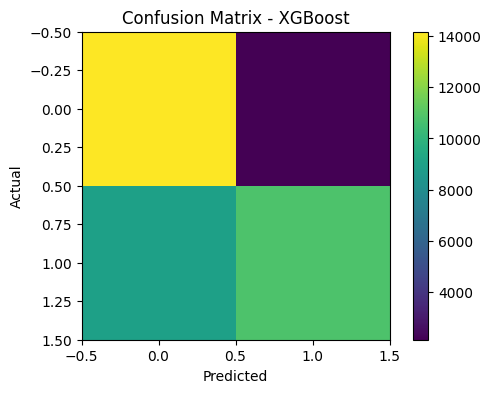

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm)
plt.colorbar()

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                              Feature  Importance
0         Days_for_shipment_scheduled    0.510095
121                Order_Country_Cuba    0.009264
103              Order_Country_Brasil    0.007956
99          Order_Country_Bielorrusia    0.006443
94            Order_Country_Bangladés    0.006317
58                      Market_Europe    0.006117
138             Order_Country_Georgia    0.006062
158              Order_Country_Italia    0.005451
142           Order_Country_Guatemala    0.005392
160               Order_Country_Japón    0.004684
184  Order_Country_Myanmar (Birmania)    0.004370
157              Order_Country_Israel    0.004354
201            Order_Country_Portugal    0.004248
34   Category_Name_Hunting & Shooting    0.004161
91            Order_Country_Australia    0.004003


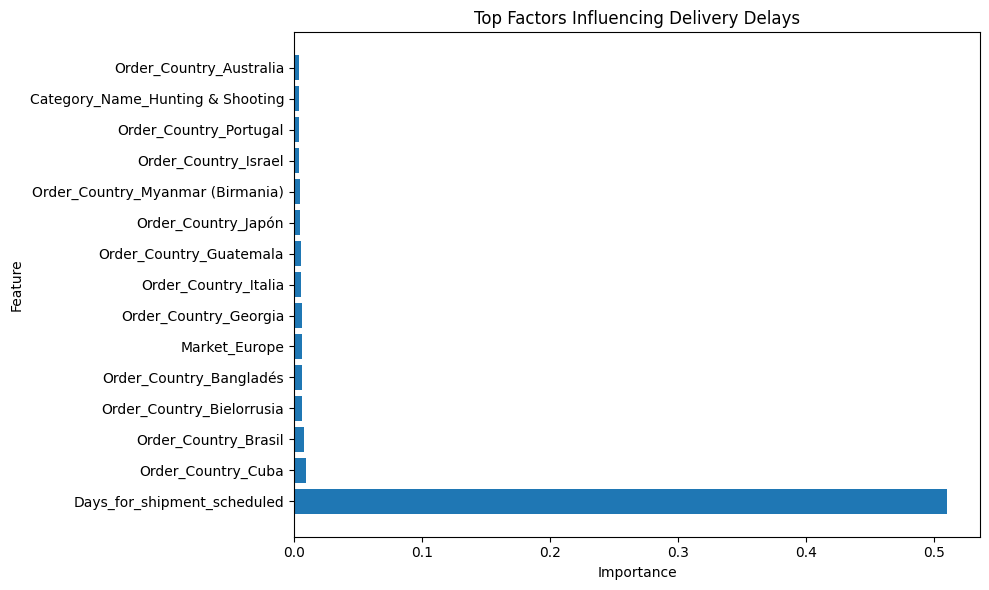

In [53]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Factors Influencing Delivery Delays"
)

plt.tight_layout()
plt.show()